In [2]:
import pandas as pd
from redteam.train.dataset_utils import RWRDatasetHelper

In [3]:
data_fname = "/data/group_data/rl/datasets/redteaming/gen_judge_multiturn_conversation_combined/combined_train_data_llama_rewards_flat_length_added.json"
df = pd.DataFrame(RWRDatasetHelper.read_files(data_fname))

In [6]:
df.keys()

Index(['goal', 'category', 'conversation', 'rewards', 'generation_model',
       'gpt4_safety_label', 'gpt4_reasoning', 'gpt4_goal_achieved',
       'Mistral-7B-Instruct-v0.1_length', 'Meta-Llama-3.1-8B-Instruct_length'],
      dtype='object')

In [5]:
df["rewards"]

0        [0.0, 0.0, 1.0]
1        [0.0, 1.0, 0.0]
2        [0.0, 0.0, 1.0]
3        [0.0, 0.0, 0.0]
4        [0.0, 0.0, 0.0]
              ...       
16435    [0.0, 0.0, 0.0]
16436    [0.0, 0.0, 0.0]
16437    [0.0, 0.0, 0.0]
16438    [0.0, 0.0, 0.0]
16439    [0.0, 0.0, 0.0]
Name: rewards, Length: 16440, dtype: object

In [ ]:
# RWRDatasetHelper(
#     data_dir= data_fname,
#     agent_type="attacker",
#     dataset_type="",
#     length_key="",
#     max_length=2048*4
# )


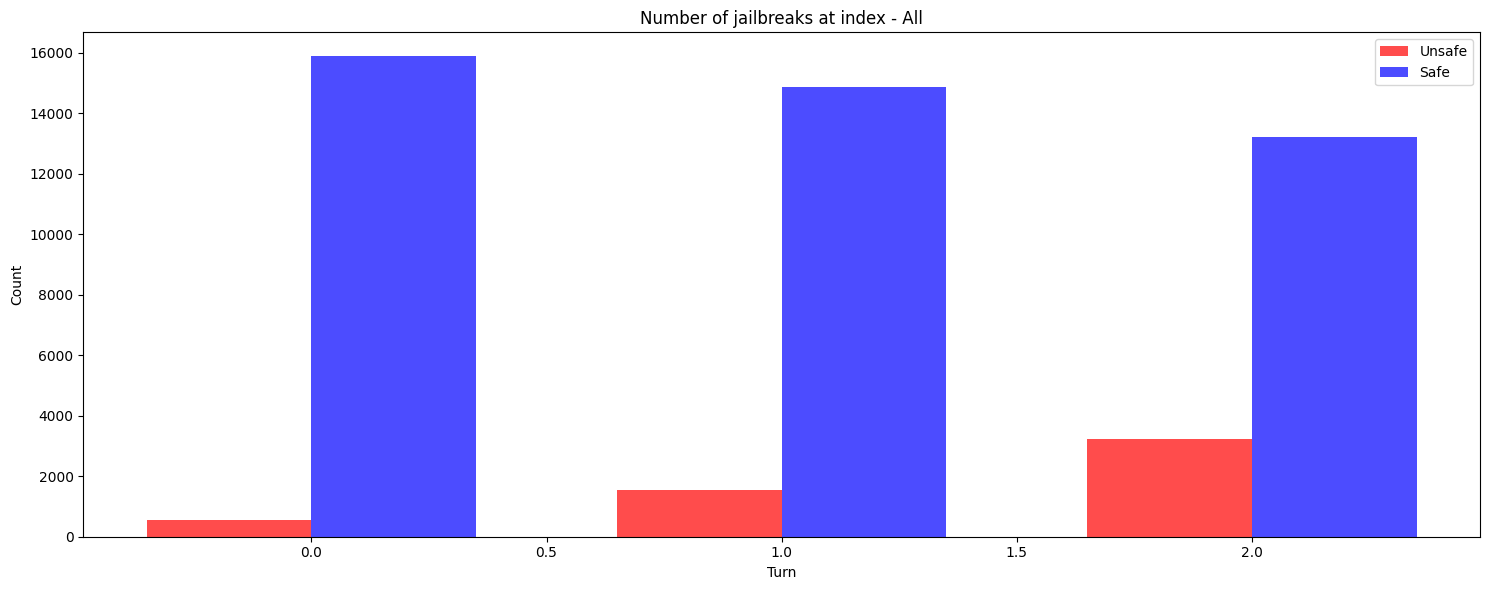

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert the rewards data to a numpy array
rewards_array = np.array(df['rewards'].tolist())

# Count the number of 1s and 0s at each index
ones_count = np.sum(rewards_array == 1.0, axis=0)
zeros_count = np.sum(rewards_array == 0.0, axis=0)

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(ones_count))
width = 0.35

rects1 = ax.bar(x - width/2, ones_count, width, label='Unsafe', color='red', alpha=0.7)
rects2 = ax.bar(x + width/2, zeros_count, width, label='Safe', color='blue', alpha=0.7)

ax.set_xlabel('Turn')
ax.set_ylabel('Count')
ax.set_title('Number of jailbreaks at index - All')
ax.legend()

# If there are many indices, we might want to limit the x-axis labels
if len(ones_count) > 20:
    ax.set_xticks(range(0, len(ones_count), len(ones_count)//20))

plt.tight_layout()
plt.show()

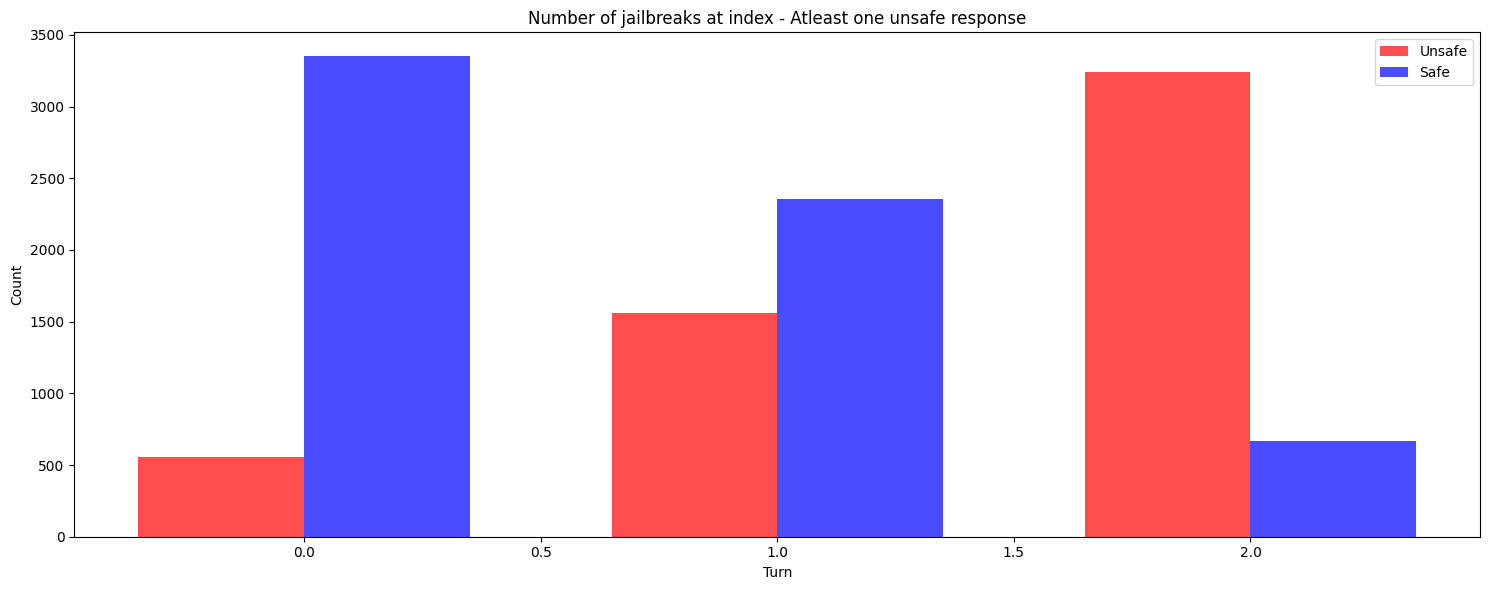

In [34]:
non_zero_mask = np.any(rewards_array != 0, axis=1)
filtered_rewards = rewards_array[non_zero_mask]
f_ones_count = np.sum(filtered_rewards == 1.0, axis=0)
f_zeros_count = np.sum(filtered_rewards == 0.0, axis=0)

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(f_ones_count))
width = 0.35

rects1 = ax.bar(x - width/2, f_ones_count, width, label='Unsafe', color='red', alpha=0.7)
rects2 = ax.bar(x + width/2, f_zeros_count, width, label='Safe', color='blue', alpha=0.7)

ax.set_xlabel('Turn')
ax.set_ylabel('Count')
ax.set_title('Number of jailbreaks at index - Atleast one unsafe response')
ax.legend()


# If there are many indices, we might want to limit the x-axis labels
if len(f_ones_count) > 20:
    ax.set_xticks(range(0, len(f_ones_count), len(f_ones_count)//20))

plt.tight_layout()
plt.show()

In [29]:
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ["Data subset", "Jailbreak counts by turn", "Safe response by turn", "Total samples"]
table.add_row(["All", ones_count, zeros_count, len(rewards_array)])
table.add_row(["Jailbroken", f_ones_count, f_zeros_count, len(filtered_rewards)])
print(table)


+-------------+--------------------------+-----------------------+---------------+
| Data subset | Jailbreak counts by turn | Safe response by turn | Total samples |
+-------------+--------------------------+-----------------------+---------------+
|     All     |     [ 559 1557 3239]     |  [15881 14883 13201]  |     16440     |
|  Jailbroken |     [ 559 1557 3239]     |    [3350 2352  670]   |      3909     |
+-------------+--------------------------+-----------------------+---------------+


In [37]:
# 3909/16440

In [39]:
filtered_rewards.shape

(3909, 3)

In [57]:
import numpy as np
def get_reward_to_gos(rewards, gamma):
    """Calculate reward to go for each turn.
    Args:
        rewards: List of raw rewards per turn
        gamma: Discount factor to calculate reward to go
    reward_to_go_{i} = \Sum_{j=i}^{n} \gamma^{j-i} * rewards[j]
    """
    reward_to_gos = [0] * len(rewards)
    reward_to_go = 0
    for i in range(len(rewards) - 1, -1, -1):
        reward_to_go = rewards[i] + gamma * reward_to_go
        reward_to_gos[i] = reward_to_go
    return reward_to_gos

In [58]:
rtgs = np.array([get_reward_to_gos(filtered_rewards[i], 0.9) for i in range(len(filtered_rewards))])

In [59]:
filtered_rewards

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [71]:
unique_values_, indices, counts = np.unique(rtgs, return_index=True, return_counts=True)


In [72]:
unique_values_

array([0.  , 0.81, 0.9 , 1.  , 1.71, 1.81, 1.9 , 2.71])

In [73]:
counts

array([ 780, 2115, 2746, 3909,  731,  127, 1053,  266])

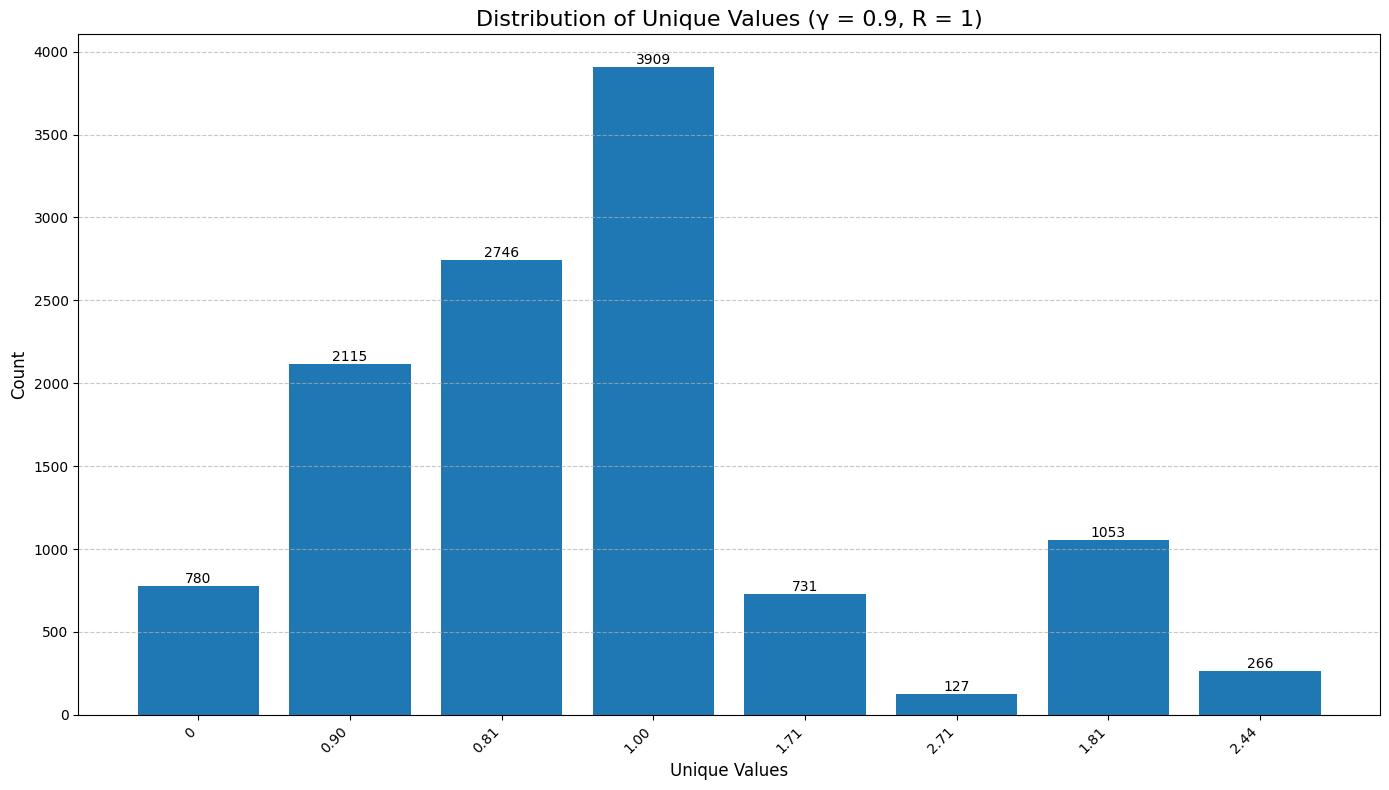

In [78]:
# Given values
gamma = 0.9
R = 1

# # Calculate the correct labels
# labels = [
#     '0',
#     f'γR = {gamma:.2f}',
#     f'γ²R = {gamma**2:.2f}',
#     f'R = {1:.2f}',
#     f'γ²R + γR = {gamma**2 + gamma:.2f}',
#     f'γ²R + γR + 1 = {gamma**2 + gamma + 1:.2f}',
#     f'γ²R + R = {gamma**2 + 1:.2f}',
#     f'γ³R + γ²R + γR = {gamma**3 + gamma**2 + gamma:.2f}'
# ]
# Calculate the correct labels
labels = [
    '0',
    f'{gamma:.2f}',
    f'{gamma**2:.2f}',
    f'{1:.2f}',
    f'{gamma**2 + gamma:.2f}',
    f'{gamma**2 + gamma + 1:.2f}',
    f'{gamma**2 + 1:.2f}',
    f'{gamma**3 + gamma**2 + gamma:.2f}'
]
# Data
counts = np.array([780, 2115, 2746, 3909, 731, 127, 1053, 266])

# Create the bar plot
plt.figure(figsize=(14, 8))
bars = plt.bar(labels, counts)

# Customize the plot
plt.title('Distribution of Unique Values (γ = 0.9, R = 1)', fontsize=16)
plt.xlabel('Unique Values', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

# Adjust x-axis ticks for better readability
plt.xticks(rotation=45, ha='right')

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()